# Bad Channel Analysis

Este notebook analiza los archivos Bad para responder tres preguntas:

1. **¿Qué tipo de fallo tiene cada canal?** — permanente, intermitente, o ruidoso
2. **¿Cuántos canales fallan en cada archivo Bad?** — fallo único o múltiple
3. **¿Es el fallo consistente en todos los eventos?** — o varía evento a evento

Todos los plots están en inglés. Código y comentarios en español.

---
## 0 · Rutas — solo toca esto

In [1]:
DAT_GOOD   = r'E:\Datos TFM\Good\Good'
DAT_BAD    = r'E:\Datos TFM\Bad\Bad'
PSIPM_FILE = r'E:\Datos TFM\psipm.tsv'
MAX_EVENTS = 200_000

---
## 1 · Imports y constantes del detector

In [2]:
import struct
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm, Normalize
from matplotlib.cm import ScalarMappable
from scipy.ndimage import gaussian_filter
from pathlib import Path

# los canales físicos van de 0 a 63, pero 3 no tienen SiPM conectado
INACTIVE   = {1, 16, 18}
ACTIVE_CH  = sorted(set(range(64)) - INACTIVE)   # lista de 61 ints
ICH_TO_IDX = {ich: i for i, ich in enumerate(ACTIVE_CH)}
IDX_TO_ICH = {i: ich for i, ich in enumerate(ACTIVE_CH)}
N          = len(ACTIVE_CH)   # 61
print(f'Canales activos: {N}')

Canales activos: 61


---
## 2 · Funciones de carga

In [3]:
def load_psipm(path):
    """
    Carga psipm.tsv sin cabecera (header=None).
    Sin esto, pandas consume la fila del canal 37 como nombre de columna
    y ese canal desaparece silenciosamente.
    """
    import pandas as pd
    df = pd.read_csv(path, sep='\t', header=None, names=['ich','xsipm','ysipm'])
    df['ich'] = df['ich'].astype(int)
    df = df[df['ich'].isin(ACTIVE_CH)].set_index('ich')
    # construir arrays en el MISMO ORDEN que ACTIVE_CH
    # critico: columna j de X corresponde a ACTIVE_CH[j]
    xs = np.array([df.loc[ich,'xsipm'] for ich in ACTIVE_CH if ich in df.index])
    ys = np.array([df.loc[ich,'ysipm'] for ich in ACTIVE_CH if ich in df.index])
    ausentes = [ich for ich in ACTIVE_CH if ich not in df.index]
    print(f'psipm: {len(df)} canales cargados  |  ausentes: {ausentes if ausentes else "ninguno"}')
    return xs, ys


def read_dat(path, max_events=200_000):
    """
    Lee datas#.dat -> matriz densa (N, 61).
    struct.unpack devuelve siempre una tupla;
    el [0] extrae el valor de la tupla de un solo elemento.
    '<f' = float32 little-endian, '<i' = int32 little-endian,
    'B'  = uint8 sin signo (Nint no puede ser negativo).
    """
    rows, nints = [], []
    with open(path, 'rb') as f:
        while len(rows) < max_events:
            b = f.read(1)
            if not b: break
            nint = struct.unpack('B', b)[0]
            if nint == 0: continue
            row, ok = np.zeros(N, np.float32), True
            for _ in range(nint):
                rb, ib = f.read(4), f.read(4)
                if len(rb) < 4 or len(ib) < 4: ok = False; break
                rch = struct.unpack('<f', rb)[0]
                ich = struct.unpack('<i', ib)[0]
                if ich in ICH_TO_IDX:
                    row[ICH_TO_IDX[ich]] = rch
            if ok:
                rows.append(row)
                nints.append(nint)
    return np.array(rows, np.float32), np.array(nints, np.int32)


def calc_positions(X, xs, ys):
    """
    Centro de gravedad ponderado por Rch^2.
    keepdims=True en sum() mantiene la dimension (N,1) para
    que la division con (N,61) funcione por broadcasting.
    clip(1e-9) evita division por cero.
    """
    r2 = X ** 2
    rt = r2.sum(axis=1, keepdims=True).clip(1e-9)
    return (r2 * xs).sum(1) / rt[:,0], (r2 * ys).sum(1) / rt[:,0]


print('Funciones listas')

Funciones listas


---
## 3 · Cargar datos

In [4]:
X_SIPM, Y_SIPM = load_psipm(PSIPM_FILE)

good_files = sorted(Path(DAT_GOOD).glob('datas*.dat'))
bad_files  = sorted(Path(DAT_BAD).glob('datas*.dat'))
print(f'Good: {[f.name for f in good_files]}')
print(f'Bad:  {[f.name for f in bad_files]}')

# usar el primer par para el analisis detallado
good_path = good_files[0]
bad_path  = bad_files[0]

print(f'\nCargando {good_path.name}...')
Xg, nig = read_dat(good_path, MAX_EVENTS)
print(f'  {len(Xg):,} eventos')

print(f'Cargando {bad_path.name}...')
Xb, nib = read_dat(bad_path, MAX_EVENTS)
print(f'  {len(Xb):,} eventos')

# clip de negativos: artefacto del ADC, no es senyal real
Xg = np.clip(Xg, 0, None)
Xb = np.clip(Xb, 0, None)

psipm: 61 canales cargados  |  ausentes: ninguno
Good: ['datas002.dat', 'datas003.dat', 'datas004.dat', 'datas006.dat', 'datas007.dat', 'datas011.dat', 'datas012.dat', 'datas013.dat', 'datas014.dat', 'datas015.dat', 'datas018.dat', 'datas019.dat', 'datas020.dat', 'datas021.dat', 'datas022.dat', 'datas023.dat', 'datas026.dat', 'datas027.dat', 'datas030.dat', 'datas031.dat', 'datas033.dat', 'datas035.dat', 'datas036.dat', 'datas037.dat', 'datas038.dat', 'datas039.dat', 'datas040.dat', 'datas043.dat', 'datas044.dat', 'datas045.dat', 'datas047.dat', 'datas048.dat', 'datas049.dat', 'datas052.dat', 'datas054.dat', 'datas055.dat', 'datas056.dat', 'datas057.dat', 'datas058.dat', 'datas062.dat', 'datas063.dat', 'datas064.dat', 'datas066.dat', 'datas067.dat', 'datas069.dat', 'datas071.dat', 'datas073.dat', 'datas075.dat', 'datas076.dat', 'datas077.dat', 'datas080.dat', 'datas081.dat', 'datas082.dat', 'datas083.dat', 'datas085.dat', 'datas086.dat', 'datas088.dat', 'datas090.dat', 'datas091.dat', 

---
## 4 · Actividad por canal — Good vs Bad

In [5]:
# axis=0 opera sobre las filas (eventos) y devuelve un valor por columna (canal)
frac_g = (Xg > 0).mean(axis=0)   # (61,) fraccion de eventos donde disparo en Good
frac_b = (Xb > 0).mean(axis=0)   # (61,) idem en Bad

# media de carga solo sobre eventos donde el canal si disparo
# Xg[Xg[:,k]>0, k] = filas donde la columna k es positiva, luego columna k
mean_g = np.array([Xg[Xg[:,k]>0,k].mean() if (Xg[:,k]>0).any() else 0. for k in range(N)])
mean_b = np.array([Xb[Xb[:,k]>0,k].mean() if (Xb[:,k]>0).any() else 0. for k in range(N)])

# ratio Bad/Good de actividad: <0.5 significa que el canal dispara menos de la mitad
ratio = frac_b / np.clip(frac_g, 1e-6, None)

dead         = np.where(frac_b < 0.01)[0]                     # muerto: <1% activo
intermittent = np.where((frac_b>=0.01) & (ratio<0.5))[0]      # intermitente: 1-50% de lo normal
suspects     = sorted(set(dead.tolist() + intermittent.tolist()))

print(f'Muertos       : {[IDX_TO_ICH[k] for k in dead]}')
print(f'Intermitentes : {[IDX_TO_ICH[k] for k in intermittent]}')
print(f'Total sospechosos: {len(suspects)}')

Muertos       : []
Intermitentes : [0, 4, 6, 14, 35, 36, 38, 48, 51, 60]
Total sospechosos: 10


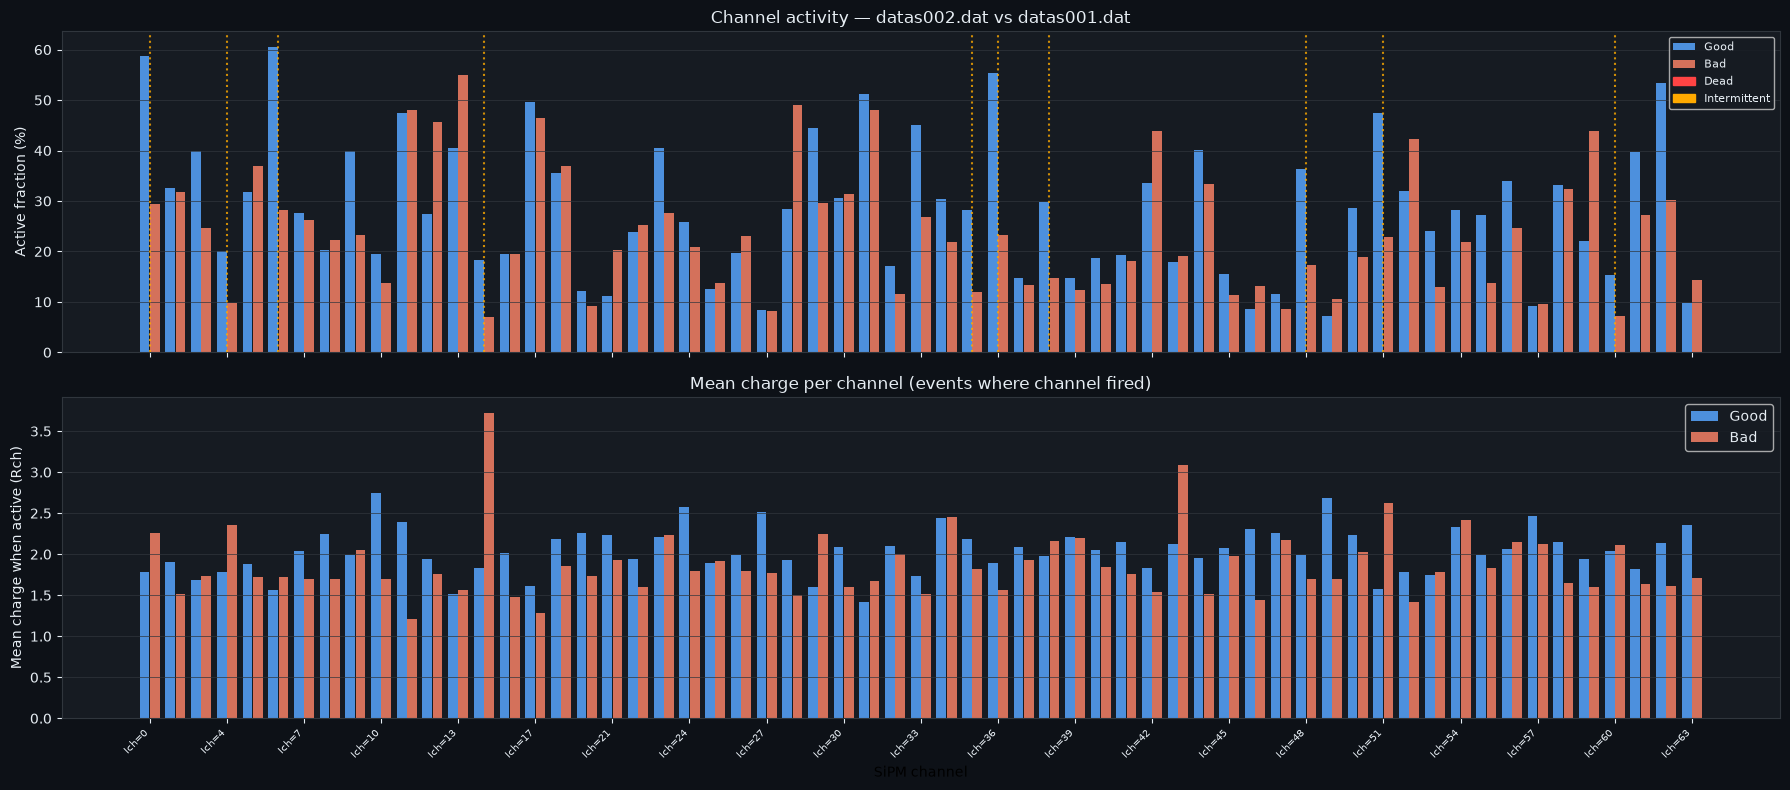

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#e6edf3')
    ax.yaxis.label.set_color('#e6edf3')
    ax.title.set_color('#e6edf3')
    ax.spines[:].set_color('#30363d')
    ax.grid(axis='y', color='#30363d', linewidth=0.5)

x = np.arange(N)
axes[0].bar(x-0.2, frac_g*100, width=0.38, label='Good', color='#58a6ff', alpha=0.85)
axes[0].bar(x+0.2, frac_b*100, width=0.38, label='Bad',  color='#f78166', alpha=0.85)
for k in dead: axes[0].axvline(k, color='#ff4444', lw=1.5, ls='--', alpha=0.8)
for k in intermittent: axes[0].axvline(k, color='#ffaa00', lw=1.5, ls=':', alpha=0.8)
axes[0].set_ylabel('Active fraction (%)')
axes[0].set_title(f'Channel activity — {good_path.name} vs {bad_path.name}')
legend_ext = [mpatches.Patch(color='#ff4444',label='Dead'),
              mpatches.Patch(color='#ffaa00',label='Intermittent')]
axes[0].legend(handles=axes[0].get_legend_handles_labels()[0]+legend_ext,
               facecolor='#161b22', labelcolor='#e6edf3', fontsize=8)

axes[1].bar(x-0.2, mean_g, width=0.38, label='Good', color='#58a6ff', alpha=0.85)
axes[1].bar(x+0.2, mean_b, width=0.38, label='Bad',  color='#f78166', alpha=0.85)
for k in dead: axes[1].axvline(k, color='#ff4444', lw=1.5, ls='--', alpha=0.8)
axes[1].set_ylabel('Mean charge when active (Rch)')
axes[1].set_title('Mean charge per channel (events where channel fired)')
axes[1].set_xticks(x[::3])
axes[1].set_xticklabels([f'Ich={IDX_TO_ICH[i]}' for i in x[::3]],
                         rotation=45, ha='right', fontsize=7, color='#e6edf3')
axes[1].set_xlabel('SiPM channel')
axes[1].legend(facecolor='#161b22', labelcolor='#e6edf3')
plt.tight_layout(); plt.show()

---
## 5 · ¿El fallo es permanente o intermitente a lo largo del tiempo?

Ich= 0  mean=29.4%  std=0.5%  -> CONSISTENTLY LOW
Ich= 4  mean=9.8%  std=0.3%  -> CONSISTENTLY LOW
Ich= 6  mean=28.3%  std=0.7%  -> CONSISTENTLY LOW
Ich=14  mean=6.9%  std=0.3%  -> CONSISTENTLY LOW
Ich=35  mean=12.0%  std=0.9%  -> CONSISTENTLY LOW
Ich=36  mean=23.2%  std=2.2%  -> CONSISTENTLY LOW
Ich=38  mean=14.8%  std=0.4%  -> CONSISTENTLY LOW
Ich=48  mean=17.3%  std=1.7%  -> CONSISTENTLY LOW
Ich=51  mean=22.9%  std=0.6%  -> CONSISTENTLY LOW
Ich=60  mean=7.1%  std=0.6%  -> CONSISTENTLY LOW


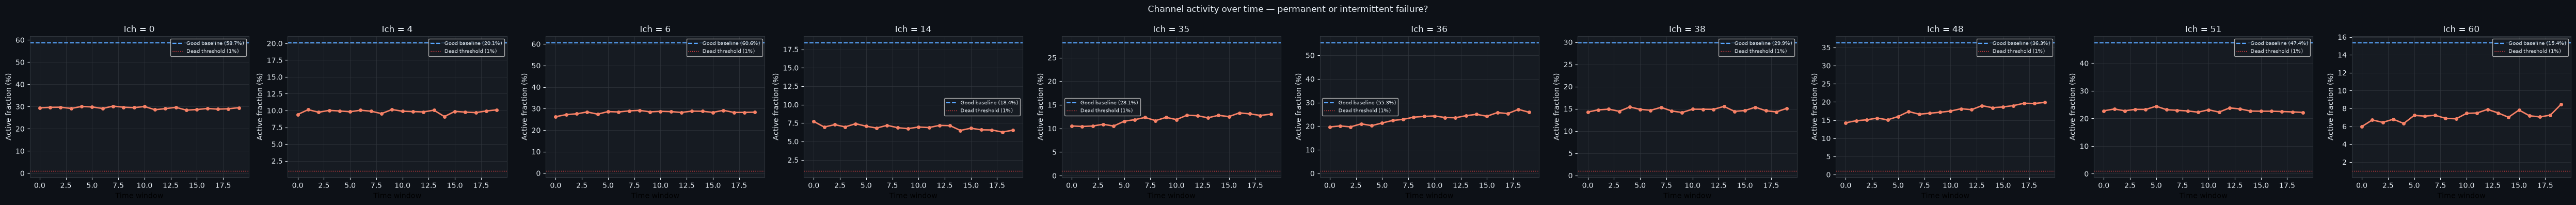

In [7]:
if not suspects:
    print('No hay canales sospechosos.')
else:
    N_WINDOWS = 20
    # np.array_split divide el indice de eventos en 20 trozos iguales
    windows = np.array_split(np.arange(len(Xb)), N_WINDOWS)

    # para cada ventana temporal, calcular fraccion activa de cada canal sospechoso
    # resultado: (N_WINDOWS, len(suspects))
    win_act = np.array([
        [(Xb[w, k] > 0).mean() for k in suspects]
        for w in windows
    ])

    # squeeze=False: aunque haya 1 subplot, axes siempre es array 2D -> axes[0,col] funciona
    fig, axes = plt.subplots(1, len(suspects), figsize=(5*len(suspects), 4), squeeze=False)
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle('Channel activity over time — permanent or intermittent failure?',
                 color='#e6edf3', fontsize=12)

    for col, k in enumerate(suspects):
        ax = axes[0, col]
        ax.set_facecolor('#161b22')
        ax.tick_params(colors='#e6edf3')
        ax.yaxis.label.set_color('#e6edf3')
        ax.title.set_color('#e6edf3')
        ax.spines[:].set_color('#30363d')
        ax.grid(color='#30363d', linewidth=0.5)
        ich = IDX_TO_ICH[k]
        ax.plot(win_act[:,col]*100, color='#f78166', lw=2, marker='o', ms=4)
        ax.axhline(frac_g[k]*100, color='#58a6ff', lw=1.5, ls='--',
                   label=f'Good baseline ({frac_g[k]*100:.1f}%)')
        ax.axhline(1.0, color='#ff4444', lw=1, ls=':', label='Dead threshold (1%)')
        ax.set_title(f'Ich = {ich}')
        ax.set_xlabel('Time window'); ax.set_ylabel('Active fraction (%)')
        ax.legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=7)

        std_act  = win_act[:,col].std()
        mean_act = win_act[:,col].mean()
        tipo = ('PERMANENT' if mean_act<0.01
                else 'INTERMITTENT' if std_act>0.05
                else 'CONSISTENTLY LOW')
        print(f'Ich={ich:2d}  mean={mean_act*100:.1f}%  std={std_act*100:.1f}%  -> {tipo}')

    plt.tight_layout(); plt.show()

---
## 6 · Flood map: Good vs Bad vs fallo simulado

Simulando fallo en Ich=0


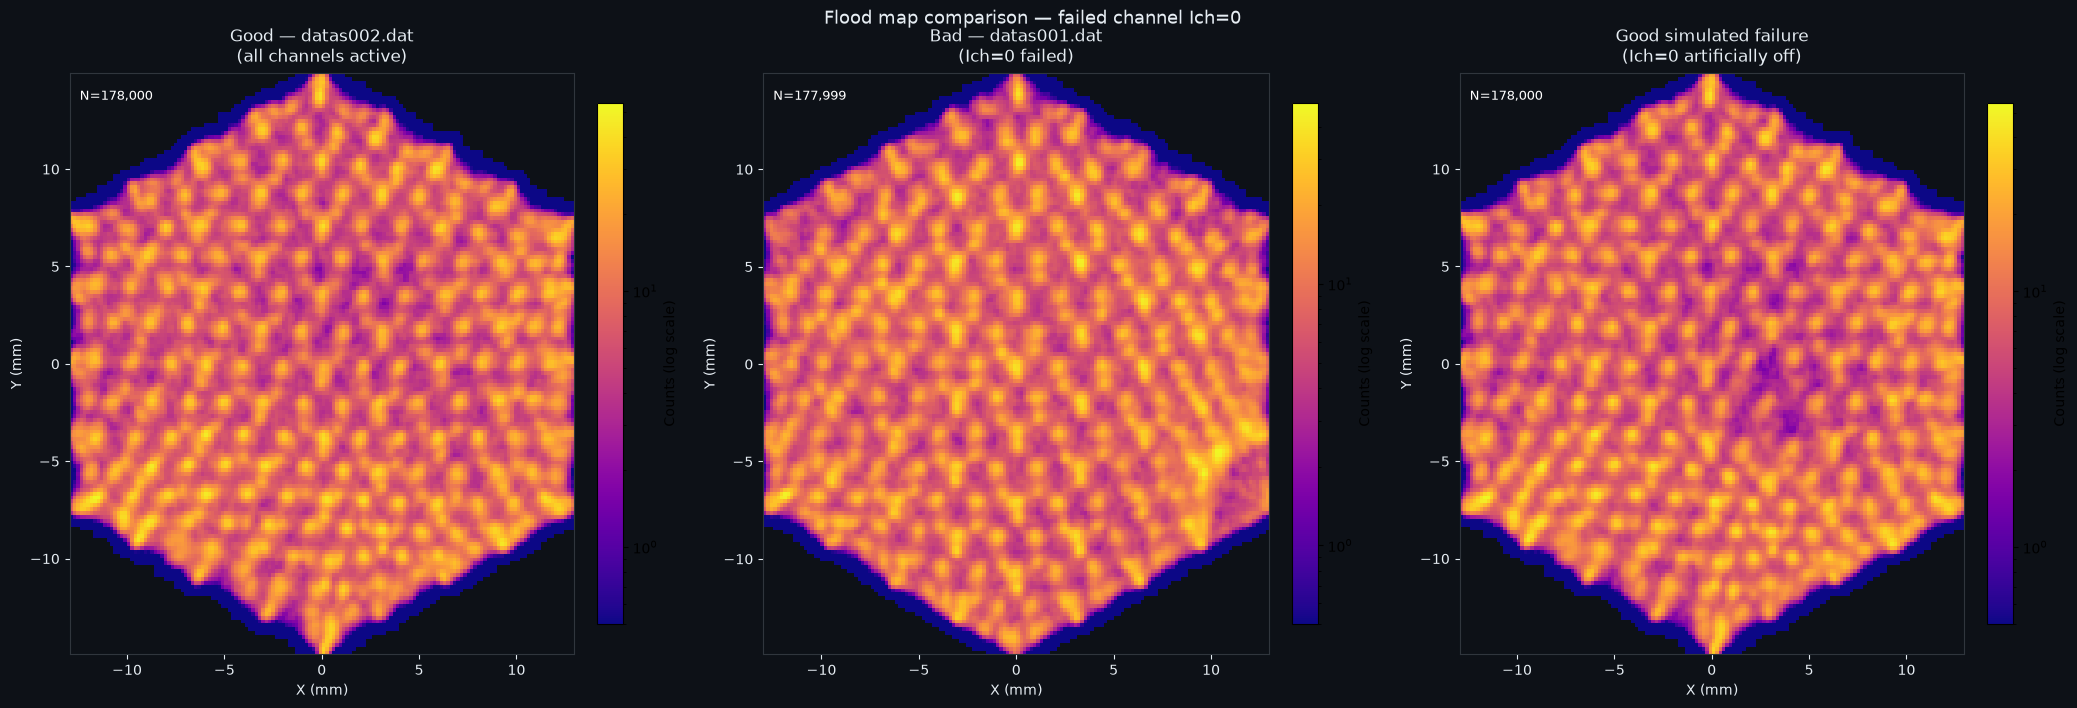

In [8]:
def make_flood_map(X, xs, ys, bins=150, sigma=0.8, p_lo=10, p_hi=99):
    """Aplica filtro de energia, calcula posiciones XY y devuelve histograma 2D."""
    rcht = X.sum(axis=1)
    lo, hi = np.percentile(rcht[rcht>0], p_lo), np.percentile(rcht[rcht>0], p_hi)
    Xf = X[(rcht>=lo)&(rcht<=hi)]
    px, py = calc_positions(Xf, xs, ys)
    lx = np.percentile(np.abs(px), 99.5)*1.2
    ly = np.percentile(np.abs(py), 99.5)*1.2
    m  = (np.abs(px)<lx)&(np.abs(py)<ly)
    px, py = px[m], py[m]
    h, xe, ye = np.histogram2d(px, py, bins=bins)
    # gaussian_filter: suavizado estetico, sigma=0 = sin suavizar
    return gaussian_filter(h, sigma) if sigma>0 else h, xe, ye, len(px)

k_kill   = suspects[0] if suspects else 0
ich_kill = IDX_TO_ICH[k_kill]
Xg_sim   = Xg.copy()
Xg_sim[:, k_kill] = 0.0   # apagar artificialmente el canal en datos Good
print(f'Simulando fallo en Ich={ich_kill}')

hg, xeg, yeg, ng   = make_flood_map(Xg,     X_SIPM, Y_SIPM)
hb, xeb, yeb, nb   = make_flood_map(Xb,     X_SIPM, Y_SIPM)
hgs, _,  _,   ngs  = make_flood_map(Xg_sim, X_SIPM, Y_SIPM)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.patch.set_facecolor('#0d1117')

for ax, h, xe, ye, n_ev, title in [
    (axes[0], hg,  xeg, yeg, ng,  f'Good — {good_path.name}\n(all channels active)'),
    (axes[1], hb,  xeb, yeb, nb,  f'Bad — {bad_path.name}\n(Ich={ich_kill} failed)'),
    (axes[2], hgs, xeg, yeg, ngs, f'Good simulated failure\n(Ich={ich_kill} artificially off)'),
]:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='#e6edf3')
    ax.xaxis.label.set_color('#e6edf3'); ax.yaxis.label.set_color('#e6edf3')
    ax.title.set_color('#e6edf3'); ax.spines[:].set_color('#30363d')
    vmin = max(0.5, h[h>0].min()) if h.max()>0 else 0.5
    # h.T transpone para que X sea el eje horizontal
    # origin='lower': el (0,0) queda abajo-izquierda (convencion fisica)
    # LogNorm: escala log para ver tanto el fondo como los picos brillantes
    im = ax.imshow(h.T, origin='lower', aspect='equal',
                   extent=[xe[0],xe[-1],ye[0],ye[-1]],
                   cmap='plasma', norm=LogNorm(vmin=vmin, vmax=h.max()))
    plt.colorbar(im, ax=ax, label='Counts (log scale)', fraction=0.046, pad=0.04)
    ax.set_title(title, pad=8); ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)')
    ax.text(0.02, 0.97, f'N={n_ev:,}', transform=ax.transAxes, va='top', color='white', fontsize=9)

plt.suptitle(f'Flood map comparison — failed channel Ich={ich_kill}',
             color='#e6edf3', fontsize=13)
plt.tight_layout(); plt.show()

---
## 7 · Mapa hexagonal: diferencia Good - Bad por canal

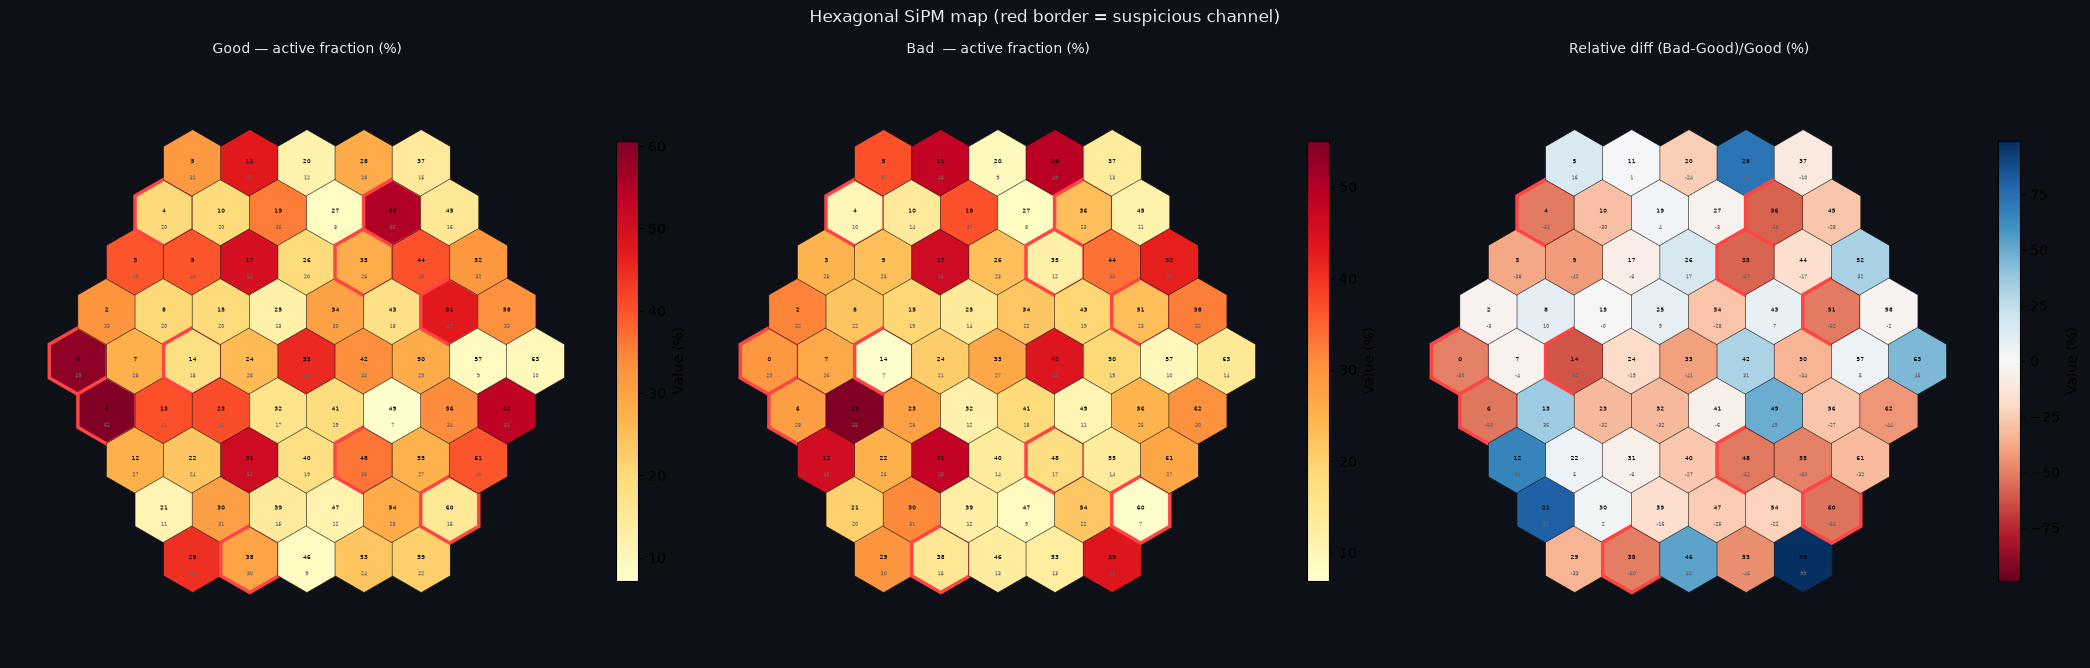

In [9]:
def hex_grid(k=5):
    """Genera coordenadas axiales (q,r) del hexagono de lado k."""
    R = k-1
    return sorted([(q,r) for q in range(-R,R+1)
                   for r in range(max(-R,-q-R), min(R,-q+R)+1)])

HEX_COORDS = hex_grid()
ICH_TO_QR  = {ich: HEX_COORDS[i] for i,ich in enumerate(ACTIVE_CH)}

def qr_to_xy(q, r):
    # coordenadas axiales -> cartesianas (pointy-top hexagon)
    return np.sqrt(3)*q + np.sqrt(3)/2*r, 3/2*r

diff = (frac_b - frac_g) / np.clip(frac_g, 1e-6, None) * 100  # diferencia relativa en %

fig, axes = plt.subplots(1, 3, figsize=(21,7))
fig.patch.set_facecolor('#0d1117')

for ax, vals, cmap_name, title in [
    (axes[0], frac_g*100, 'YlOrRd', 'Good — active fraction (%)'),
    (axes[1], frac_b*100, 'YlOrRd', 'Bad  — active fraction (%)'),
    (axes[2], diff,       'RdBu',   'Relative diff (Bad-Good)/Good (%)'),
]:
    ax.set_facecolor('#0d1117'); ax.axis('off')
    ax.set_title(title, color='#e6edf3', pad=8, fontsize=10)
    lim  = np.abs(vals).max()
    norm = Normalize(vmin=-lim, vmax=lim) if cmap_name=='RdBu' else Normalize(vmin=vals.min(), vmax=vals.max())
    cmap_obj = plt.get_cmap(cmap_name)

    for di in range(N):
        ich    = IDX_TO_ICH[di]
        cx, cy = qr_to_xy(*ICH_TO_QR[ich])
        color  = cmap_obj(norm(vals[di]))
        # borde rojo en canales sospechosos para destacarlos
        edge = '#ff4444' if di in suspects else '#111'
        lw   = 2.5 if di in suspects else 0.4
        ax.add_patch(mpatches.RegularPolygon(
            (cx,cy), numVertices=6, radius=0.88*2/np.sqrt(3),
            orientation=0, facecolor=color, edgecolor=edge, linewidth=lw))
        ax.text(cx, cy+0.05, str(ich), ha='center', va='center',
                fontsize=4.5, color='black')
        ax.text(cx, cy-0.45, f'{vals[di]:.0f}', ha='center', va='center',
                fontsize=3.5, color='#666')

    ax.set_xlim(-9,9); ax.set_ylim(-9,9); ax.set_aspect('equal')
    sm = ScalarMappable(cmap=cmap_obj, norm=norm); sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Value (%)', fraction=0.035, pad=0.02)

plt.suptitle('Hexagonal SiPM map (red border = suspicious channel)',
             color='#e6edf3', fontsize=12)
plt.tight_layout(); plt.show()

---
## 8 · Resumen de todos los archivos Bad

In [10]:
print(f'{"File":<22} {"Events":>10} {"Dead channels":>20} {"Intermittent":>18}')
print('-'*75)
summary = []
for bp in bad_files:
    Xf, _ = read_dat(bp, max_events=50_000)
    Xf    = np.clip(Xf, 0, None)
    ff    = (Xf>0).mean(axis=0)
    rf    = ff / np.clip(frac_g, 1e-6, None)
    dead_f  = [IDX_TO_ICH[k] for k in np.where(ff<0.01)[0]]
    inter_f = [IDX_TO_ICH[k] for k in np.where((ff>=0.01)&(rf<0.5))[0]]
    summary.append({'file':bp.name,'n':len(Xf),'dead':dead_f,'inter':inter_f})
    print(f'{bp.name:<22} {len(Xf):>10,} {str(dead_f):>20} {str(inter_f):>18}')

print('\nChannels that appear dead in at least one Bad file:')
from collections import Counter
# Counter cuenta cuantas veces aparece cada elemento en la lista aplanada
c = Counter(ich for s in summary for ich in s['dead'])
for ich, cnt in sorted(c.items(), key=lambda x: -x[1]):
    print(f'  Ich={ich:2d}  dead in {cnt}/{len(bad_files)} bad files')

File                       Events        Dead channels       Intermittent
---------------------------------------------------------------------------
datas001.dat               50,000                   [] [4, 6, 14, 35, 36, 38, 48, 51, 55, 60, 62]
datas005.dat               50,000                   []       [36, 51, 55]
datas008.dat               50,000                   []           [33, 44]
datas009.dat               50,000                   [] [0, 9, 14, 17, 19, 24, 30, 31, 35, 36, 37, 44, 45, 48, 50, 51, 53, 55, 56, 58]
datas010.dat               50,000                   []           [36, 38]
datas016.dat               50,000                 [59]   [17, 35, 38, 60]
datas017.dat               50,000                   [] [6, 8, 9, 10, 11, 13, 14, 17, 22, 23, 24, 30, 35, 38, 42, 44, 51, 53, 55]
datas024.dat               50,000                   [] [27, 31, 36, 48, 55, 58, 62]
datas025.dat               50,000                   []           [34, 35]
datas028.dat               50,000  

---
## 9 · Distribucion de Rch del canal sospechoso

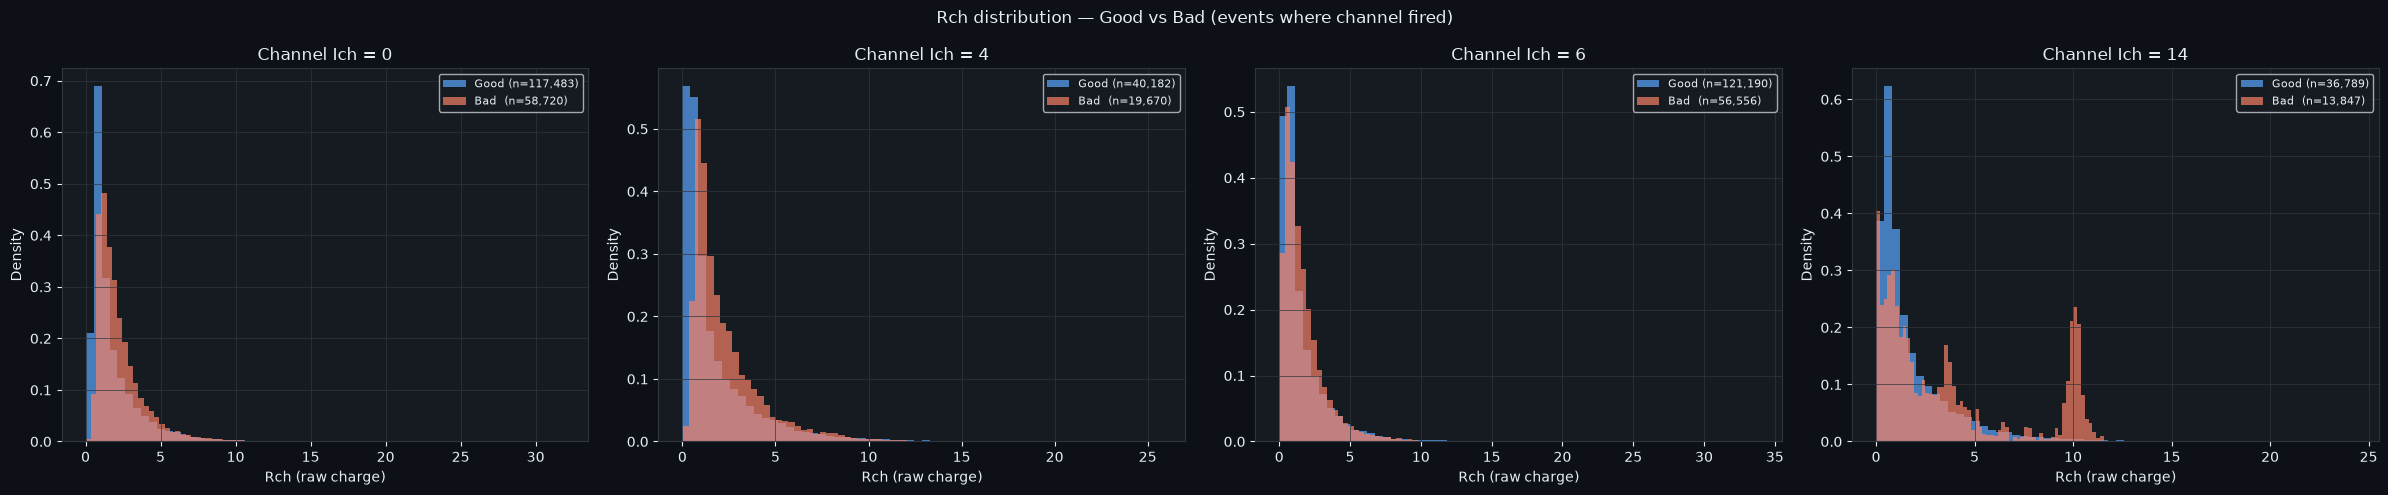

In [11]:
if not suspects:
    print('No suspicious channels.')
else:
    show = suspects[:4]
    fig, axes = plt.subplots(1, len(show), figsize=(6*len(show),5), squeeze=False)
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle('Rch distribution — Good vs Bad (events where channel fired)',
                 color='#e6edf3', fontsize=12)

    for col, k in enumerate(show):
        ich = IDX_TO_ICH[k]
        ax  = axes[0, col]
        ax.set_facecolor('#161b22')
        ax.tick_params(colors='#e6edf3')
        ax.yaxis.label.set_color('#e6edf3'); ax.xaxis.label.set_color('#e6edf3')
        ax.title.set_color('#e6edf3'); ax.spines[:].set_color('#30363d')
        ax.grid(color='#30363d', linewidth=0.5)

        # Xg[Xg[:,k]>0, k] = seleccionar filas donde canal k>0, luego tomar esa columna
        rg = Xg[Xg[:,k]>0, k]
        rb = Xb[Xb[:,k]>0, k]

        if len(rg)>10: ax.hist(rg, bins=60, color='#58a6ff', alpha=0.7,
                               density=True, label=f'Good (n={len(rg):,})')
        if len(rb)>10: ax.hist(rb, bins=60, color='#f78166', alpha=0.7,
                               density=True, label=f'Bad  (n={len(rb):,})')
        else: ax.text(0.5,0.5, f'Only {len(rb)} events fired\n-> effectively dead',
                      ha='center',va='center',transform=ax.transAxes,
                      color='#ff4444',fontsize=10)

        ax.set_title(f'Channel Ich = {ich}')
        ax.set_xlabel('Rch (raw charge)'); ax.set_ylabel('Density')
        ax.legend(facecolor='#161b22', labelcolor='#e6edf3', fontsize=8)

    plt.tight_layout(); plt.show()